## Loading Packages

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

df = pd.read_csv("https://raw.githubusercontent.com/hovhannisyan91/data_analytics_with_python/refs/heads/main/data/regression/logistic_regression/synthetic_churn_data.csv")
print(f"Dataset shape: {df.shape}")
df.head()


df.to_csv("../data/raw/synthetic_churn_data.csv", index=False)

Dataset shape: (1000, 6)


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tenure           1000 non-null   int64  
 1   monthly_charges  1000 non-null   float64
 2   support_calls    1000 non-null   int64  
 3   contract_type    1000 non-null   int64  
 4   churn            1000 non-null   int64  
 5   education_level  1000 non-null   str    
dtypes: float64(1), int64(4), str(1)
memory usage: 53.8 KB


### Exploratory Data Analysis


In [3]:
churn_rate_by_contract = df.groupby('contract_type')['churn'].mean().reset_index()
import plotly.express as px
fig = px.bar(
    churn_rate_by_contract,
    x = 'contract_type',
    y = 'churn',
    title = 'Churn Rate by Contract Type'
)

fig.update_layout(
    xaxis_title = 'Contract Type (0 = Prepaid, 1 = Postpaid',
    yaxis_title = 'Churn Rate',
    template = 'plotly_white'
)

fig.show()

### Churn Rate by Education Level


In [4]:
churn_rate_by_education = df.groupby('education_level')['churn'].mean().reset_index()

fig = px.bar(
    churn_rate_by_education,
    x='education_level',
    y='churn',
    title='Churn Rate by Education Level'
)

fig.update_layout(
    xaxis_title='Education Level',
    yaxis_title='Churn Rate',
    template='plotly_white'
)

fig.show()

### Data Preprocessing


In [5]:
X = df.drop(columns=['churn'])
y = df['churn']

#### Encoding Categorical Variables


In [6]:
education_order = ["High Scholl", "Bachelor", "Master", "PhD"]

df["education_level"] = pd.Categorical(
    df["education_level"],
    categories = education_order,
    ordered=True
)

education_dummies = pd.get_dummies(
    df["education_level"],
    prefix="education",
    drop_first=True,
    dtype=int
)

education_dummies.head()

C:\Users\User\AppData\Local\Temp\ipykernel_6272\3041287934.py:3: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df["education_level"] = pd.Categorical(


,education_Bachelor,education_Master,education_PhD
0,0,0,0
1,1,0,0
2,0,1,0
3,0,0,0
4,0,1,0


In [7]:
X_encoded = pd.concat([X.drop(columns=["education_level"]), education_dummies], axis=1)

X_encoded.head()

,tenure,monthly_charges,support_calls,contract_type,education_Bachelor,education_Master,education_PhD
0,29,46.867736,6,0,0,0,0
1,15,74.163421,6,0,1,0,0
2,8,83.347822,3,1,0,1,0
3,21,45.788769,2,0,0,0,0
4,19,33.935607,7,0,0,1,0


#### Checking the final set of features


In [8]:
print('Final set of features:')
print(X_encoded.dtypes)

Final set of features:
tenure                  int64
monthly_charges       float64
support_calls           int64
contract_type           int64
education_Bachelor      int64
education_Master        int64
education_PhD           int64
dtype: object


### Train-Test Split


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
X_train, X_test, y_train, y_test


(     tenure  monthly_charges  support_calls  contract_type  \
 494      32        51.615610              6              0   
 687      26        52.433375              5              0   
 720      31        32.771348              2              0   
 381      33       100.172808              0              0   
 3        21        45.788769              2              0   
 ..      ...              ...            ...            ...   
 139      24        93.758230              8              1   
 565       3        57.325179              4              1   
 503      14       106.791829              9              0   
 759      20       106.201448              0              1   
 551      22        96.228513              0              0   
 
      education_Bachelor  education_Master  education_PhD  
 494                   1                 0              0  
 687                   0                 0              0  
 720                   1                 0              0  
 3

In [11]:
train_size = len(X_train)
test_size =len(X_test)

train_churn_rate = y_train.mean()
test_churn_rate = y_test.mean()

print("Training rows:", train_size)
print("Test rows:", test_size)
print("Training churn rate:", round(train_churn_rate, 3))
print("Test churn rate:", round(test_churn_rate, 3))

Training rows: 800
Test rows: 200
Training churn rate: 0.368
Test churn rate: 0.365


### Training the Logistic Regression Model


In [12]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

### Predicting Probabilities on the Test Set


In [13]:
probs = model.predict_proba(X_test)
probs[:5]

array([[0.98318865, 0.01681135],
       [0.58270693, 0.41729307],
       [0.5251156 , 0.4748844 ],
       [0.38401881, 0.61598119],
       [0.67937097, 0.32062903]])

In [14]:
probs = probs[:, 1]
probs[:5]

array([0.01681135, 0.41729307, 0.4748844 , 0.61598119, 0.32062903])

### Converting the Probabilities into Binary Predictions


In [15]:
threshold = 0.5
preds = (probs >= threshold).astype(int)
preds[:5]

array([0, 0, 0, 1, 0])

### Previewing the Predictions


In [16]:
prediction_results = X_test.copy()

prediction_results["actual_churn"] = y_test.values
prediction_results["predicted_probability"] = probs
prediction_results["predicted_churn"] = preds

prediction_results.head()

,tenure,monthly_charges,support_calls,contract_type,education_Bachelor,education_Master,education_PhD,actual_churn,predicted_probability,predicted_churn
361,34,55.062693,2,1,0,0,0,0,0.016811,0
5,23,103.493024,4,0,0,0,1,0,0.417293,0
692,25,75.778342,5,0,0,1,0,1,0.474884,0
708,6,112.717782,5,1,0,1,0,0,0.615981,1
841,26,67.601813,7,1,0,0,1,0,0.320629,0


### Coefficient Interpretation with Exponentiated Betas


In [18]:
coef_df = pd.DataFrame({
    "feature": X_encoded.columns,
    "beta": model.coef_[0],
    "exp_beta": np.exp(model.coef_[0])
})

coef_df = coef_df.sort_values("exp_beta", ascending=False)
coef_df

,feature,beta,exp_beta
2,support_calls,0.569331,1.767085
4,education_Bachelor,0.122822,1.130683
5,education_Master,0.112243,1.118784
1,monthly_charges,0.020345,1.020553
0,tenure,-0.055288,0.946213
6,education_PhD,-0.226199,0.797560
3,contract_type,-1.228919,0.292609


### Confusion Matrix

In [19]:
cm = confusion_matrix(y_test, preds)
tn, fp, fn, tp = cm.ravel()
cm

array([[103,  24],
       [ 23,  50]])

### Classification Metrics

In [20]:
print("Accuracy:", round(accuracy_score(y_test, preds), 3))
print("Precision:", round(precision_score(y_test, preds), 3))
print("Recall:", round(recall_score(y_test, preds), 3))

Accuracy: 0.765
Precision: 0.676
Recall: 0.685


### ROC Կոր և AUC (Area Under the Curve)

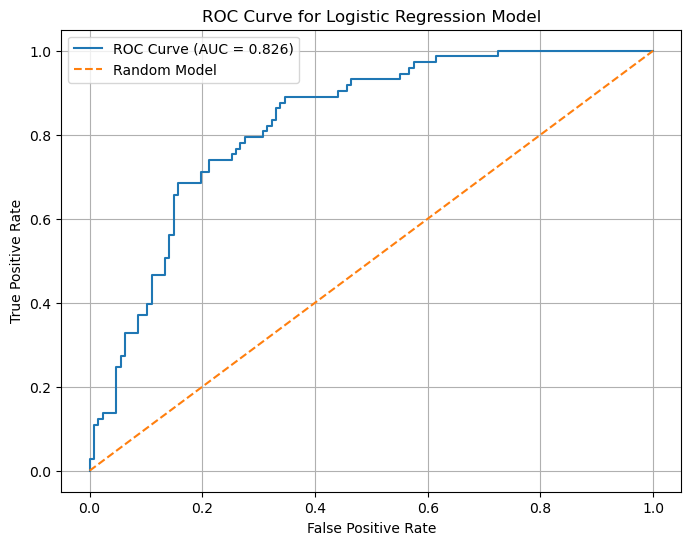

In [24]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, probs)
auc_score = roc_auc_score(y_test, probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label = f"ROC Curve (AUC = {auc_score:.3f})")
plt.plot([0,1], [0, 1], linestyle="--", label="Random Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Logistic Regression Model")
plt.legend()
plt.grid(True)
plt.show()


### Revenue Matrix

In [25]:
retention_cost = 10
retention_benefit = 50

revenue_from_saved_customers = tp * (retention_benefit - retention_cost)
cost_from_unnecessary_contacts = fp * retention_cost
net_profit = revenue_from_saved_customers - cost_from_unnecessary_contacts

print("Revenue from saved customers:", revenue_from_saved_customers)
print("Cost from unnecessary contacts:", cost_from_unnecessary_contacts)
print("Net profit:", net_profit)

Revenue from saved customers: 2000
Cost from unnecessary contacts: 240
Net profit: 1760
